In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

# emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
# emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
# #emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
extent = 1
llc_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent))
# emulator_patch = emulator_patch_full.isel(time=slice(0, extent))#(9216, 9216 + extent))#(0, extent))

In [4]:
# # Rename lat/lon to j/i
# emulator_patch = emulator_patch.rename({'lat': 'j', 'lon': 'i'})

# # Copy over coordinates from llc_patch
# emulator_patch['XC'] = llc_patch['XC']
# emulator_patch['YC'] = llc_patch['YC']
# emulator_patch['rA'] = llc_patch['rA']
# emulator_patch['Z'] = llc_patch['Z']

In [5]:
omega = 7.2921e-5

# LLC Patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

vort_llc = ((np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2 - \
            (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2)

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
#vort_llc_normalized = np.clip(vort_llc_normalized, np.nanpercentile(vort_llc_normalized, 1), np.nanpercentile(vort_llc_normalized, 99))
vort_llc_normalized = vort_llc_normalized / np.nanmax(np.abs(vort_llc_normalized))

llc_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)
llc_patch['vorticity_no_coriolis'] = (('time', 'k', 'j', 'i'), vort_llc / np.nanmax(np.abs(vort_llc)))

In [6]:
# # Emulator Patch
# f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

# vort_emulator = ((np.roll(emulator_patch['V'].values, -1, axis=3) - np.roll(emulator_patch['V'].values, 1, axis=3)) / 2 - \
#                  (np.roll(emulator_patch['U'].values, -1, axis=2) - np.roll(emulator_patch['U'].values, 1, axis=2)) / 2)

# vort_emulator_normalized = vort_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]
# #vort_emulator_normalized = np.clip(vort_emulator_normalized, np.nanpercentile(vort_emulator_normalized, 1), np.nanpercentile(vort_emulator_normalized, 99))
# vort_emulator_normalized = vort_emulator_normalized / np.nanmax(np.abs(vort_emulator_normalized))

# emulator_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_emulator_normalized)

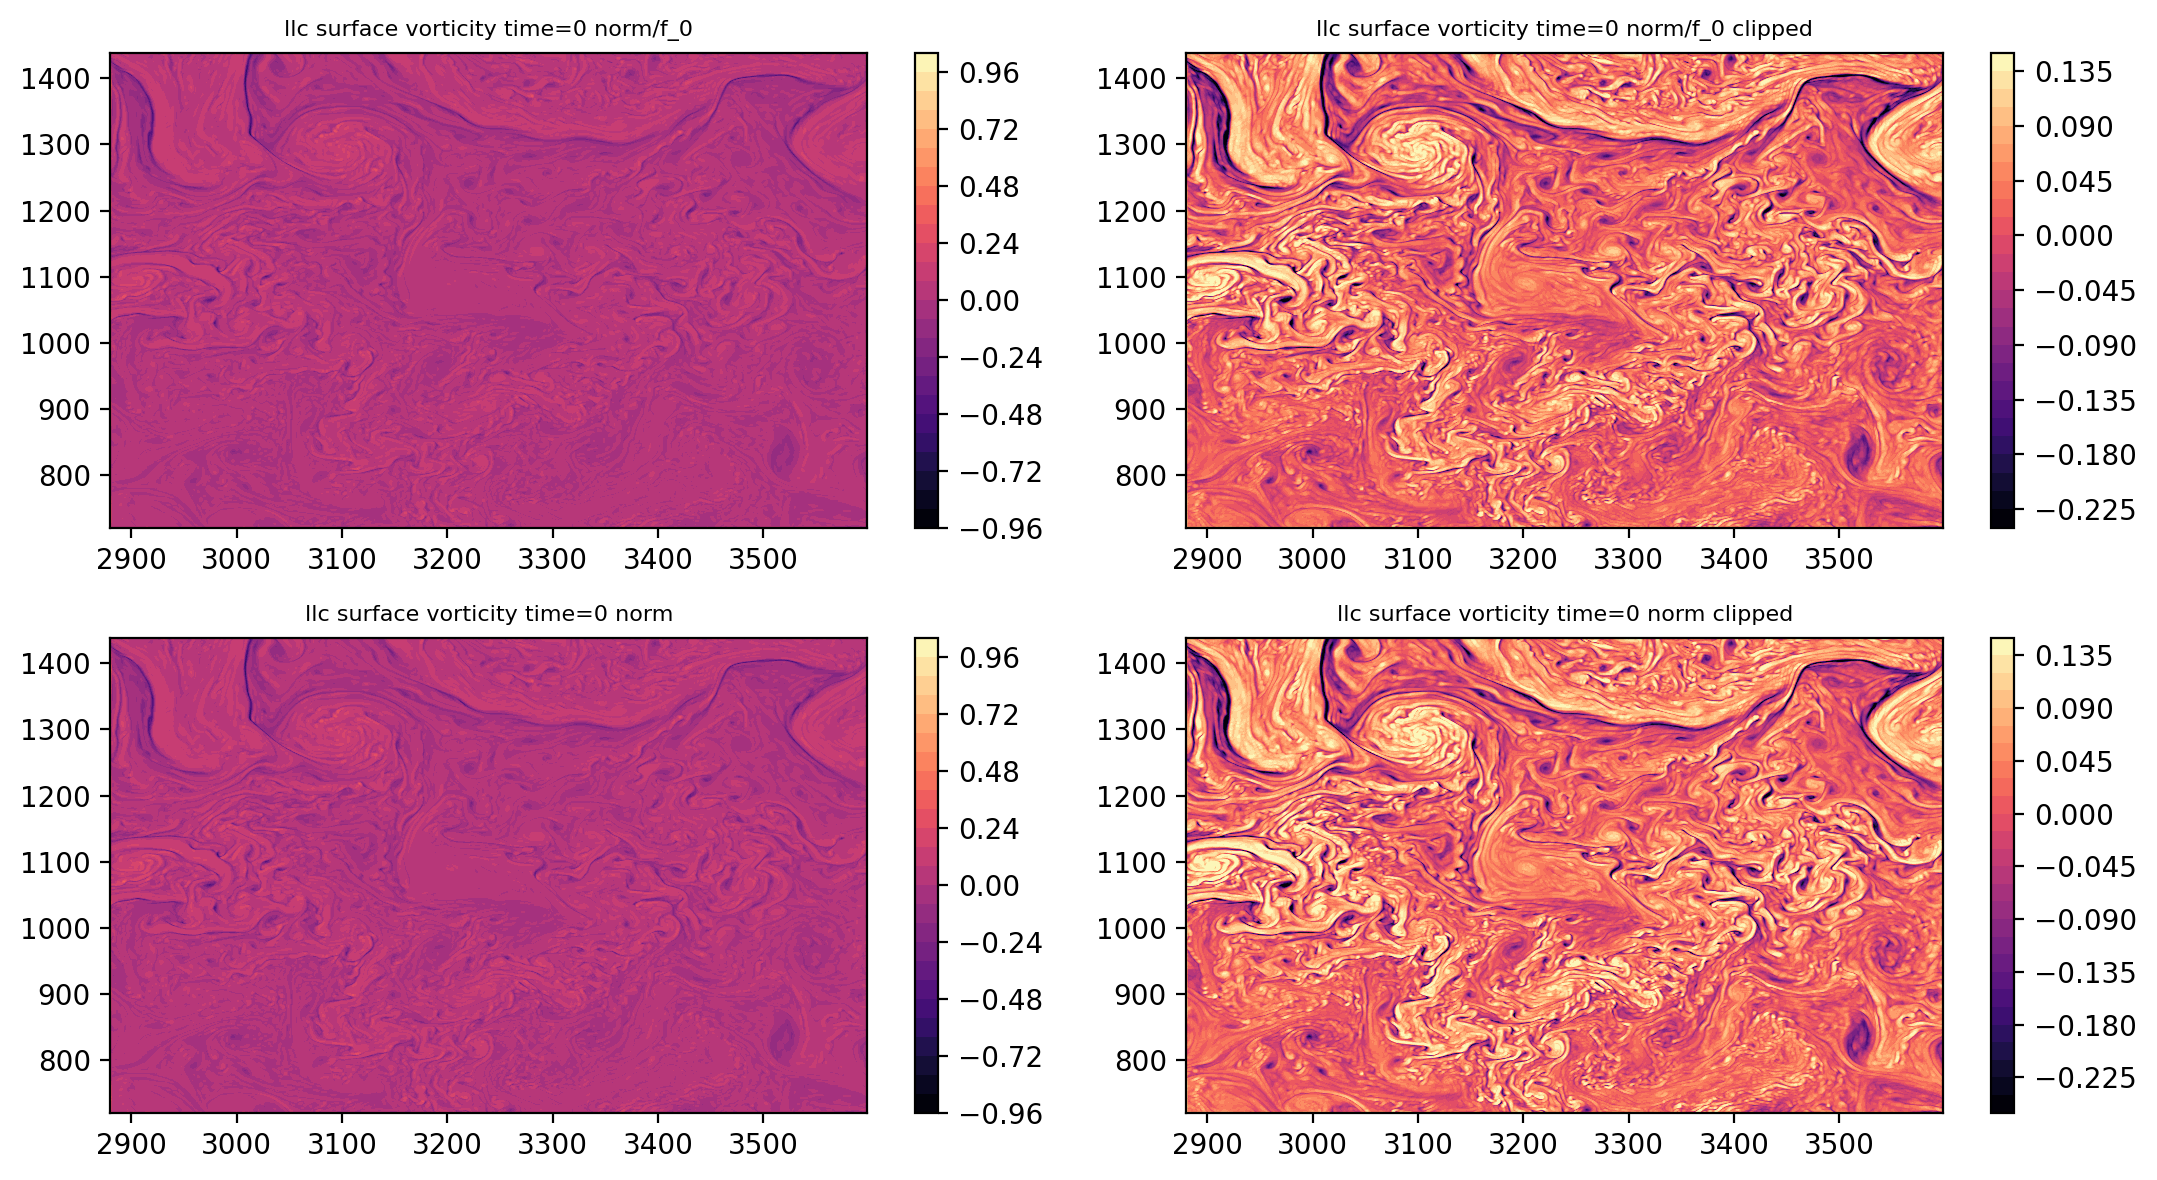

In [7]:
llc_vis = llc_patch.isel(time=0,k=0).vorticity
#emulator_vis = emulator_patch.isel(time=0,k=0).vorticity

fig, ([[ax1, ax2], [ax3,ax4]]) = plt.subplots(2, 2, figsize=(11, 6), dpi=200)

# LLC
cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="magma", levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface vorticity time=0 norm/f_0', fontsize=8)

llc_vis2 = np.clip(llc_vis, np.nanpercentile(llc_vis, 1), np.nanpercentile(llc_vis, 99))
cf2 = ax2.contourf(llc_vis2.coords.get('i', np.arange(llc_vis2.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis2.shape[-2])), llc_vis2, \
        cmap="magma", levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('llc surface vorticity time=0 norm/f_0 clipped', fontsize=8)

llc_vis3 = llc_patch.isel(time=0,k=0).vorticity_no_coriolis
cf3 = ax3.contourf(llc_vis3.coords.get('i', np.arange(llc_vis3.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis3.shape[-2])), llc_vis3, \
        cmap="magma", levels=30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc surface vorticity time=0 norm', fontsize=8)

llc_vis4 = np.clip(llc_vis3, np.nanpercentile(llc_vis3, 1), np.nanpercentile(llc_vis3, 99))
cf4 = ax4.contourf(llc_vis4.coords.get('i', np.arange(llc_vis4.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis4.shape[-2])), llc_vis4, \
        cmap="magma", levels=30)
plt.colorbar(cf4, ax=ax4)
ax4.set_title('llc surface vorticity time=0 norm clipped', fontsize=8)


# # Emulator
# vmin_emu = float(emulator_vis.quantile(0.01))
# vmax_emu = float(emulator_vis.quantile(0.99))
# cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
#     emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
#         cmap="magma", vmin=vmin_emu, vmax=vmax_emu, levels=30)
# plt.colorbar(cf2, ax=ax2)
# ax2.set_title('emulator surface vorticity time=0', fontsize=8)

# # Difference
# diff = llc_vis - emulator_vis
# vmin_diff = float(diff.quantile(0.01))
# vmax_diff = float(diff.quantile(0.99))
# cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
#     emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
#         cmap="bwr", vmin=vmin_diff, vmax=vmax_diff, levels=30)
# plt.colorbar(cf3, ax=ax3)
# ax3.set_title('llc - emulator time=0', fontsize=8)

plt.tight_layout()
plt.show()


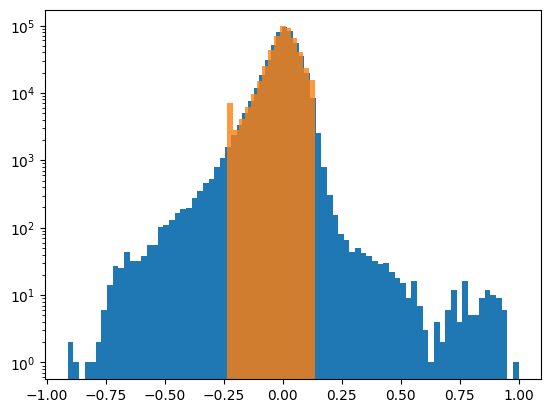

In [8]:
plt.hist(llc_vis.stack(dims=['j','i']),bins=80)
plt.yscale('log')
plt.hist(llc_vis2.stack(dims=['j','i']),alpha=0.8,bins=15)
plt.yscale('log')

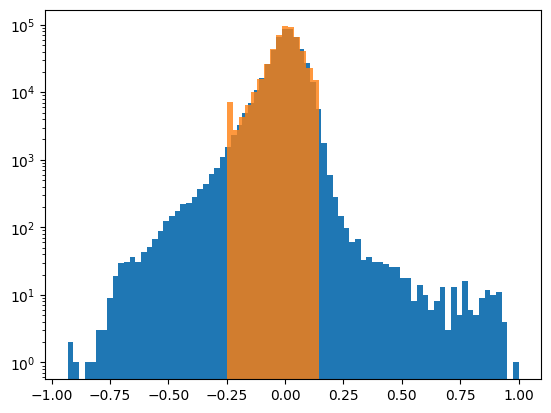

In [9]:
plt.hist(llc_vis3.stack(dims=['j','i']),bins=80)
plt.yscale('log')
plt.hist(llc_vis4.stack(dims=['j','i']),alpha=0.8,bins=15)
plt.yscale('log')

In [ ]:
omega = 7.2921e-5

# LLC Patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

u_x_llc = (np.roll(llc_patch['U'].values, -1, axis=3) - np.roll(llc_patch['U'].values, 1, axis=3)) / 2
u_y_llc = (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2
v_x_llc = (np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2
v_y_llc = (np.roll(llc_patch['V'].values, -1, axis=2) - np.roll(llc_patch['V'].values, 1, axis=2)) / 2

sigma_n_llc = u_x_llc - v_y_llc
sigma_s_llc = v_x_llc + u_y_llc
sigma_llc = np.sqrt(sigma_n_llc**2 + sigma_s_llc**2)

sigma_llc_normalized = sigma_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
#sigma_llc_normalized = np.clip(sigma_llc_normalized, 0, np.nanpercentile(sigma_llc_normalized, 99))
sigma_llc_normalized = sigma_llc_normalized / np.nanmax(sigma_llc_normalized)

llc_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_llc_normalized)
llc_patch['strain_no_coriolis'] = (('time', 'k', 'j', 'i'), sigma_llc / np.nanmax(np.abs(sigma_llc)))

In [ ]:
# # Emulator Patch
# f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

# u_x_emulator = (np.roll(emulator_patch['U'].values, -1, axis=3) - np.roll(emulator_patch['U'].values, 1, axis=3)) / 2
# u_y_emulator = (np.roll(emulator_patch['U'].values, -1, axis=2) - np.roll(emulator_patch['U'].values, 1, axis=2)) / 2
# v_x_emulator = (np.roll(emulator_patch['V'].values, -1, axis=3) - np.roll(emulator_patch['V'].values, 1, axis=3)) / 2
# v_y_emulator = (np.roll(emulator_patch['V'].values, -1, axis=2) - np.roll(emulator_patch['V'].values, 1, axis=2)) / 2

# sigma_n_emulator = u_x_emulator - v_y_emulator
# sigma_s_emulator = v_x_emulator + u_y_emulator
# sigma_emulator = np.sqrt(sigma_n_emulator**2 + sigma_s_emulator**2)

# sigma_emulator_normalized = sigma_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]
# sigma_emulator_normalized = np.clip(sigma_emulator_normalized, 0, np.nanpercentile(sigma_emulator_normalized, 99))
# sigma_emulator_normalized = sigma_emulator_normalized / np.nanmax(sigma_emulator_normalized)

# emulator_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_emulator_normalized)

Text(0.5, 1.0, 'llc surface strain time=0 norm clipped')

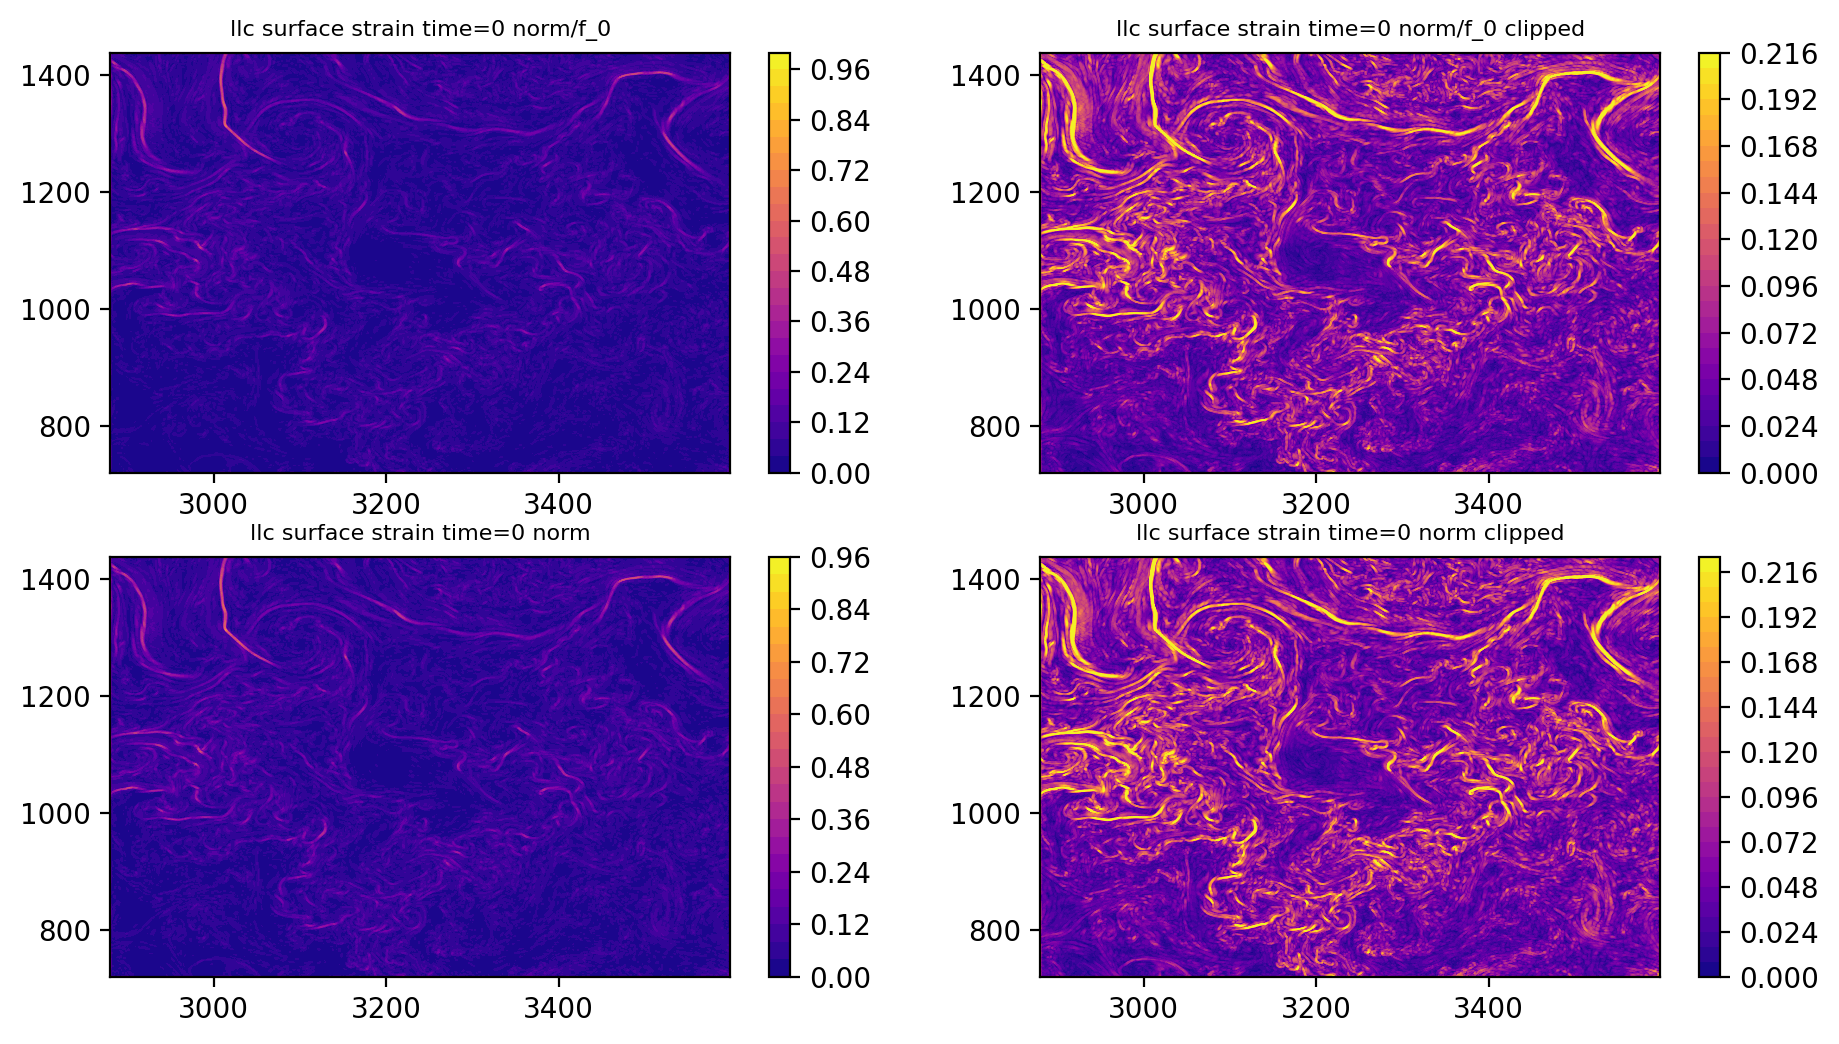

In [ ]:
llc_vis = llc_patch.isel(time=0,k=0).strain
#emulator_vis = emulator_patch.isel(time=0,k=0).strain

fig, ([[ax1, ax2], [ax3,ax4]]) = plt.subplots(2, 2, figsize=(11, 6), dpi=200)

# LLC
cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma", levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface strain time=0 norm/f_0', fontsize=8)

llc_vis2 = np.clip(llc_vis, 0, np.nanpercentile(llc_vis, 99))
cf2 = ax2.contourf(llc_vis2.coords.get('i', np.arange(llc_vis2.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis2.shape[-2])), llc_vis2, \
        cmap="plasma", levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('llc surface strain time=0 norm/f_0 clipped', fontsize=8)

llc_vis3 = llc_patch.isel(time=0,k=0).strain_no_coriolis
cf3 = ax3.contourf(llc_vis3.coords.get('i', np.arange(llc_vis3.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis3.shape[-2])), llc_vis3, \
        cmap="plasma", levels=30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc surface strain time=0 norm', fontsize=8)

llc_vis4 = np.clip(llc_vis3, 0, np.nanpercentile(llc_vis3, 99))
cf4 = ax4.contourf(llc_vis4.coords.get('i', np.arange(llc_vis4.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis4.shape[-2])), llc_vis4, \
        cmap="plasma", levels=30)
plt.colorbar(cf4, ax=ax4)
ax4.set_title('llc surface strain time=0 norm clipped', fontsize=8)

In [4]:
# LLC Patch
Theta_llc = llc_patch['Theta'].values  # load once

dT_di_llc = (np.roll(Theta_llc, -1, axis=3) - np.roll(Theta_llc, 1, axis=3)) / 2
dT_dj_llc = (np.roll(Theta_llc, -1, axis=2) - np.roll(Theta_llc, 1, axis=2)) / 2

# Gradient magnitude |∇T|
grad_T_llc = np.sqrt(dT_di_llc**2 + dT_dj_llc**2)

llc_patch['grad_T'] = (('time', 'k', 'j', 'i'), grad_T_llc/np.nanmax(grad_T_llc))

# # Emulator Patch
# Theta_emulator = emulator_patch['Theta'].values  # load once

# dT_di_emulator = (np.roll(Theta_emulator, -1, axis=3) - np.roll(Theta_emulator, 1, axis=3)) / 2
# dT_dj_emulator = (np.roll(Theta_emulator, -1, axis=2) - np.roll(Theta_emulator, 1, axis=2)) / 2

# grad_T_emulator = np.sqrt(dT_di_emulator**2 + dT_dj_emulator**2)

# emulator_patch['grad_T'] = (('time', 'k', 'j', 'i'), grad_T_emulator)

In [7]:
llc_patch.grad_T

<xarray.DataArray 'grad_T' (time: 1, k: 51, j: 720, i: 720)> Size: 106MB
array([[[[7.4801528e-01, 7.0212841e-01, 6.9728422e-01, ...,
          9.5438778e-01, 9.4880015e-01, 9.7860742e-01],
         [2.4772608e-01, 1.5728300e-03, 8.1180397e-04, ...,
          1.6377611e-02, 1.8862637e-02, 2.5091219e-01],
         [2.3732881e-01, 6.3443132e-04, 1.5758259e-04, ...,
          1.9469921e-02, 1.9212632e-02, 2.4067274e-01],
         ...,
         [9.5798718e-03, 1.6398367e-02, 1.1410764e-02, ...,
          1.8662040e-03, 7.3490585e-03, 1.3442913e-02],
         [1.2610550e-02, 9.8752603e-03, 3.8759923e-03, ...,
          3.6782373e-03, 7.0924661e-03, 4.7714021e-03],
         [6.9775420e-01, 7.0194280e-01, 7.0253998e-01, ...,
          9.6164638e-01, 9.5806366e-01, 9.5529127e-01]],

        [[7.4799365e-01, 7.0167273e-01, 6.9680315e-01, ...,
          9.5538658e-01, 9.4980437e-01, 9.7985792e-01],
         [2.4882127e-01, 1.5460658e-03, 7.9688692e-04, ...,
          1.6280448e-02, 1.8811062e-02, 2.5201589e-01],
         [2.3836243e-01, 6.1602081e-04, 1.4906566e-04, ...,
          1.9537311e-02, 1.9321918e-02, 2.4175160e-01],
...
         [1.3880379e-02, 1.6848274e-02, 3.3541527e-02, ...,
          4.7203586e-03, 2.9382361e-03, 7.0189638e-03],
         [3.9734859e-02, 2.5955554e-02, 1.5660418e-02, ...,
          4.2603738e-03, 5.1082689e-03, 1.6153635e-02],
         [2.1959665e-01, 2.0699985e-01, 2.0708765e-01, ...,
          3.0299276e-01, 3.0277312e-01, 3.0819052e-01]],

        [[1.8812081e-01, 1.7988318e-01, 1.9460939e-01, ...,
          2.7114376e-01, 2.7354193e-01, 2.8345284e-01],
         [6.4470604e-02, 3.3700000e-03, 4.0137465e-03, ...,
          4.3542986e-03, 3.8267891e-03, 6.5033540e-02],
         [6.4956449e-02, 2.0620043e-03, 3.5927552e-03, ...,
          6.6551543e-04, 1.0321182e-03, 6.5318875e-02],
         ...,
         [2.2317590e-02, 1.4330123e-03, 2.9325854e-02, ...,
          2.4674190e-03, 2.8460633e-03, 7.6772296e-03],
         [2.9223954e-02, 3.5710644e-02, 1.0173658e-02, ...,
          1.6472570e-03, 3.5851379e-03, 7.0389835e-03],
         [2.0573184e-01, 1.9025631e-01, 1.8382879e-01, ...,
          2.6856095e-01, 2.6933351e-01, 2.7358502e-01]]]], dtype=float32)
Coordinates:
  * i        (i) int16 1kB 2880 2881 2882 2883 2884 ... 3595 3596 3597 3598 3599
  * j        (j) int16 1kB 720 721 722 723 724 725 ... 1435 1436 1437 1438 1439
  * k        (k) int16 102B 0 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 8B 2012-10-01

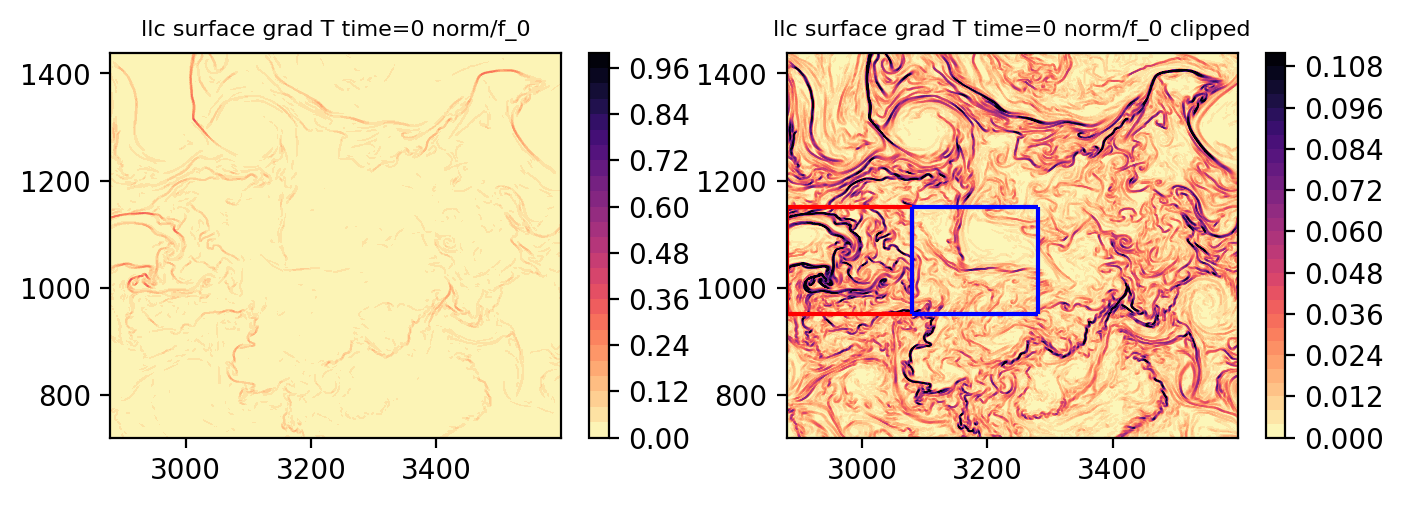

In [11]:
llc_vis = llc_patch.grad_T.isel(time=0,k=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.5), dpi=200)

# LLC
cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="magma_r", levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface grad T time=0 norm/f_0', fontsize=8)



llc_vis2 = np.clip(llc_vis, np.nanpercentile(llc_vis, 1), np.nanpercentile(llc_vis, 99))
cf2 = ax2.contourf(llc_vis2.coords.get('i', np.arange(llc_vis2.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis2.shape[-2])), llc_vis2, \
        cmap="magma_r", levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('llc surface grad T time=0 norm/f_0 clipped', fontsize=8)

i_0 = 2880
i_1 = 3080
j_0 = 950
j_1 = 1150

ax2.hlines(y=j_0, xmin=i_0, xmax=i_1, colors='r')
ax2.hlines(y=j_1, xmin=i_0, xmax=i_1, colors='r')
ax2.vlines(x=i_0, ymin=j_0, ymax=j_1, colors='r')
ax2.vlines(x=i_1, ymin=j_0, ymax=j_1, colors='r')

i_0 = 3080
i_1 = 3280
j_0 = 950
j_1 = 1150

ax2.hlines(y=j_0, xmin=i_0, xmax=i_1, colors='b')
ax2.hlines(y=j_1, xmin=i_0, xmax=i_1, colors='b')
ax2.vlines(x=i_0, ymin=j_0, ymax=j_1, colors='b')
ax2.vlines(x=i_1, ymin=j_0, ymax=j_1, colors='b')

In [15]:
vort_hist_llc = llc_patch.vorticity.stack(vals=['time','i','j']).values
# vort_hist_emulator = emulator_patch.vorticity.stack(vals=['time','i','j']).values

strain_hist_llc = llc_patch.strain.stack(vals=['time','i','j']).values
# strain_hist_emulator = emulator_patch.strain.stack(vals=['time','i','j']).values

grad_T_hist_llc = llc_patch.grad_T.stack(vals=['time','i','j']).values
# grad_T_hist_emulator = emulator_patch.grad_T.stack(vals=['time','i','j']).values

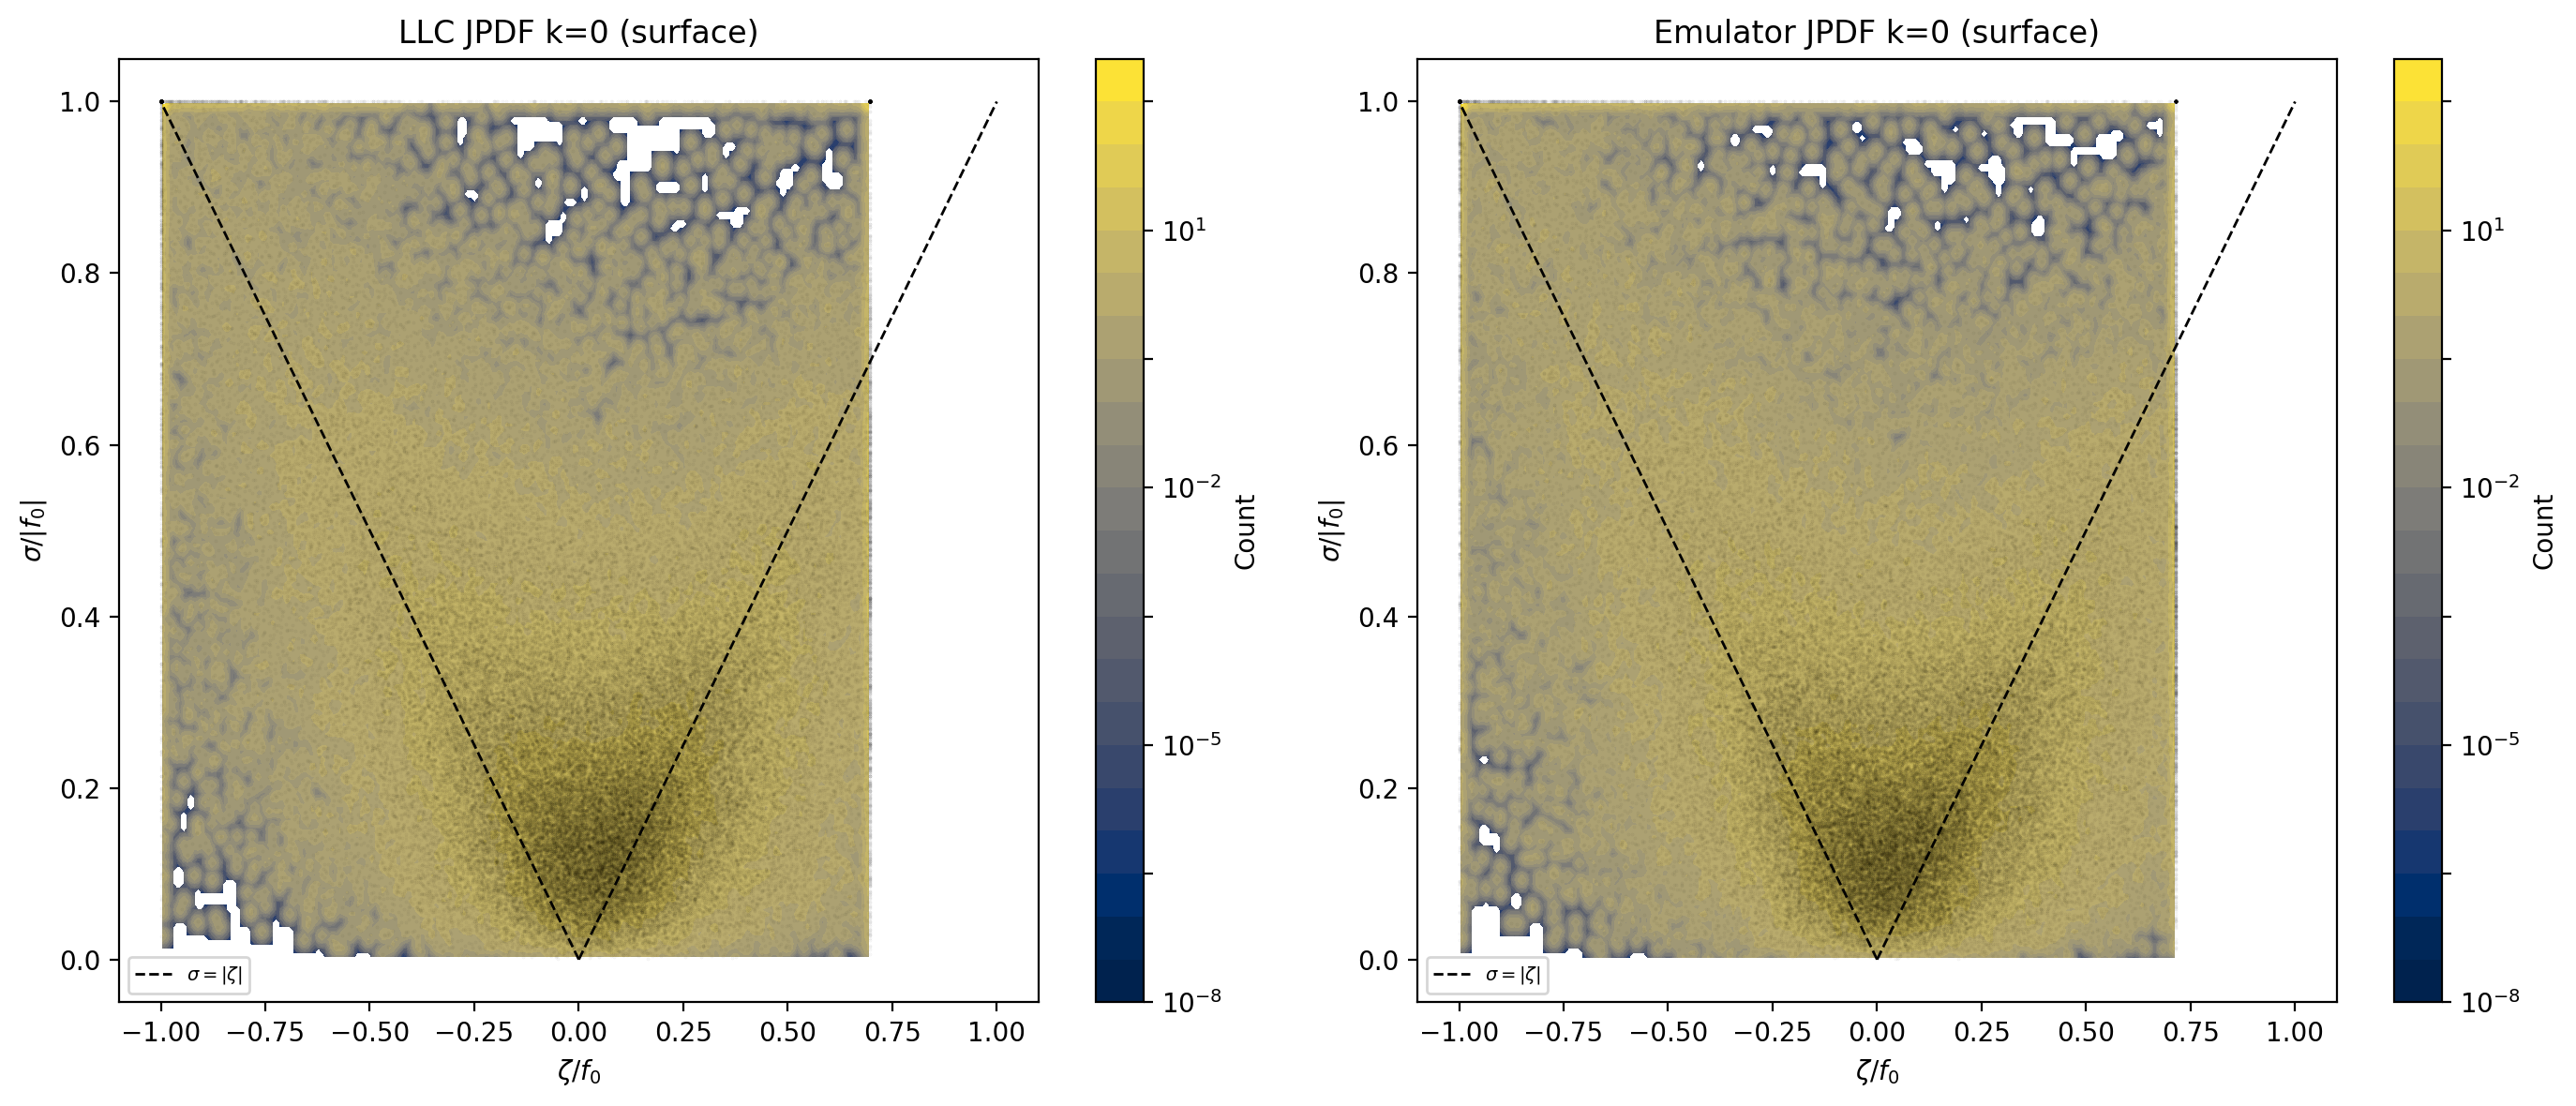

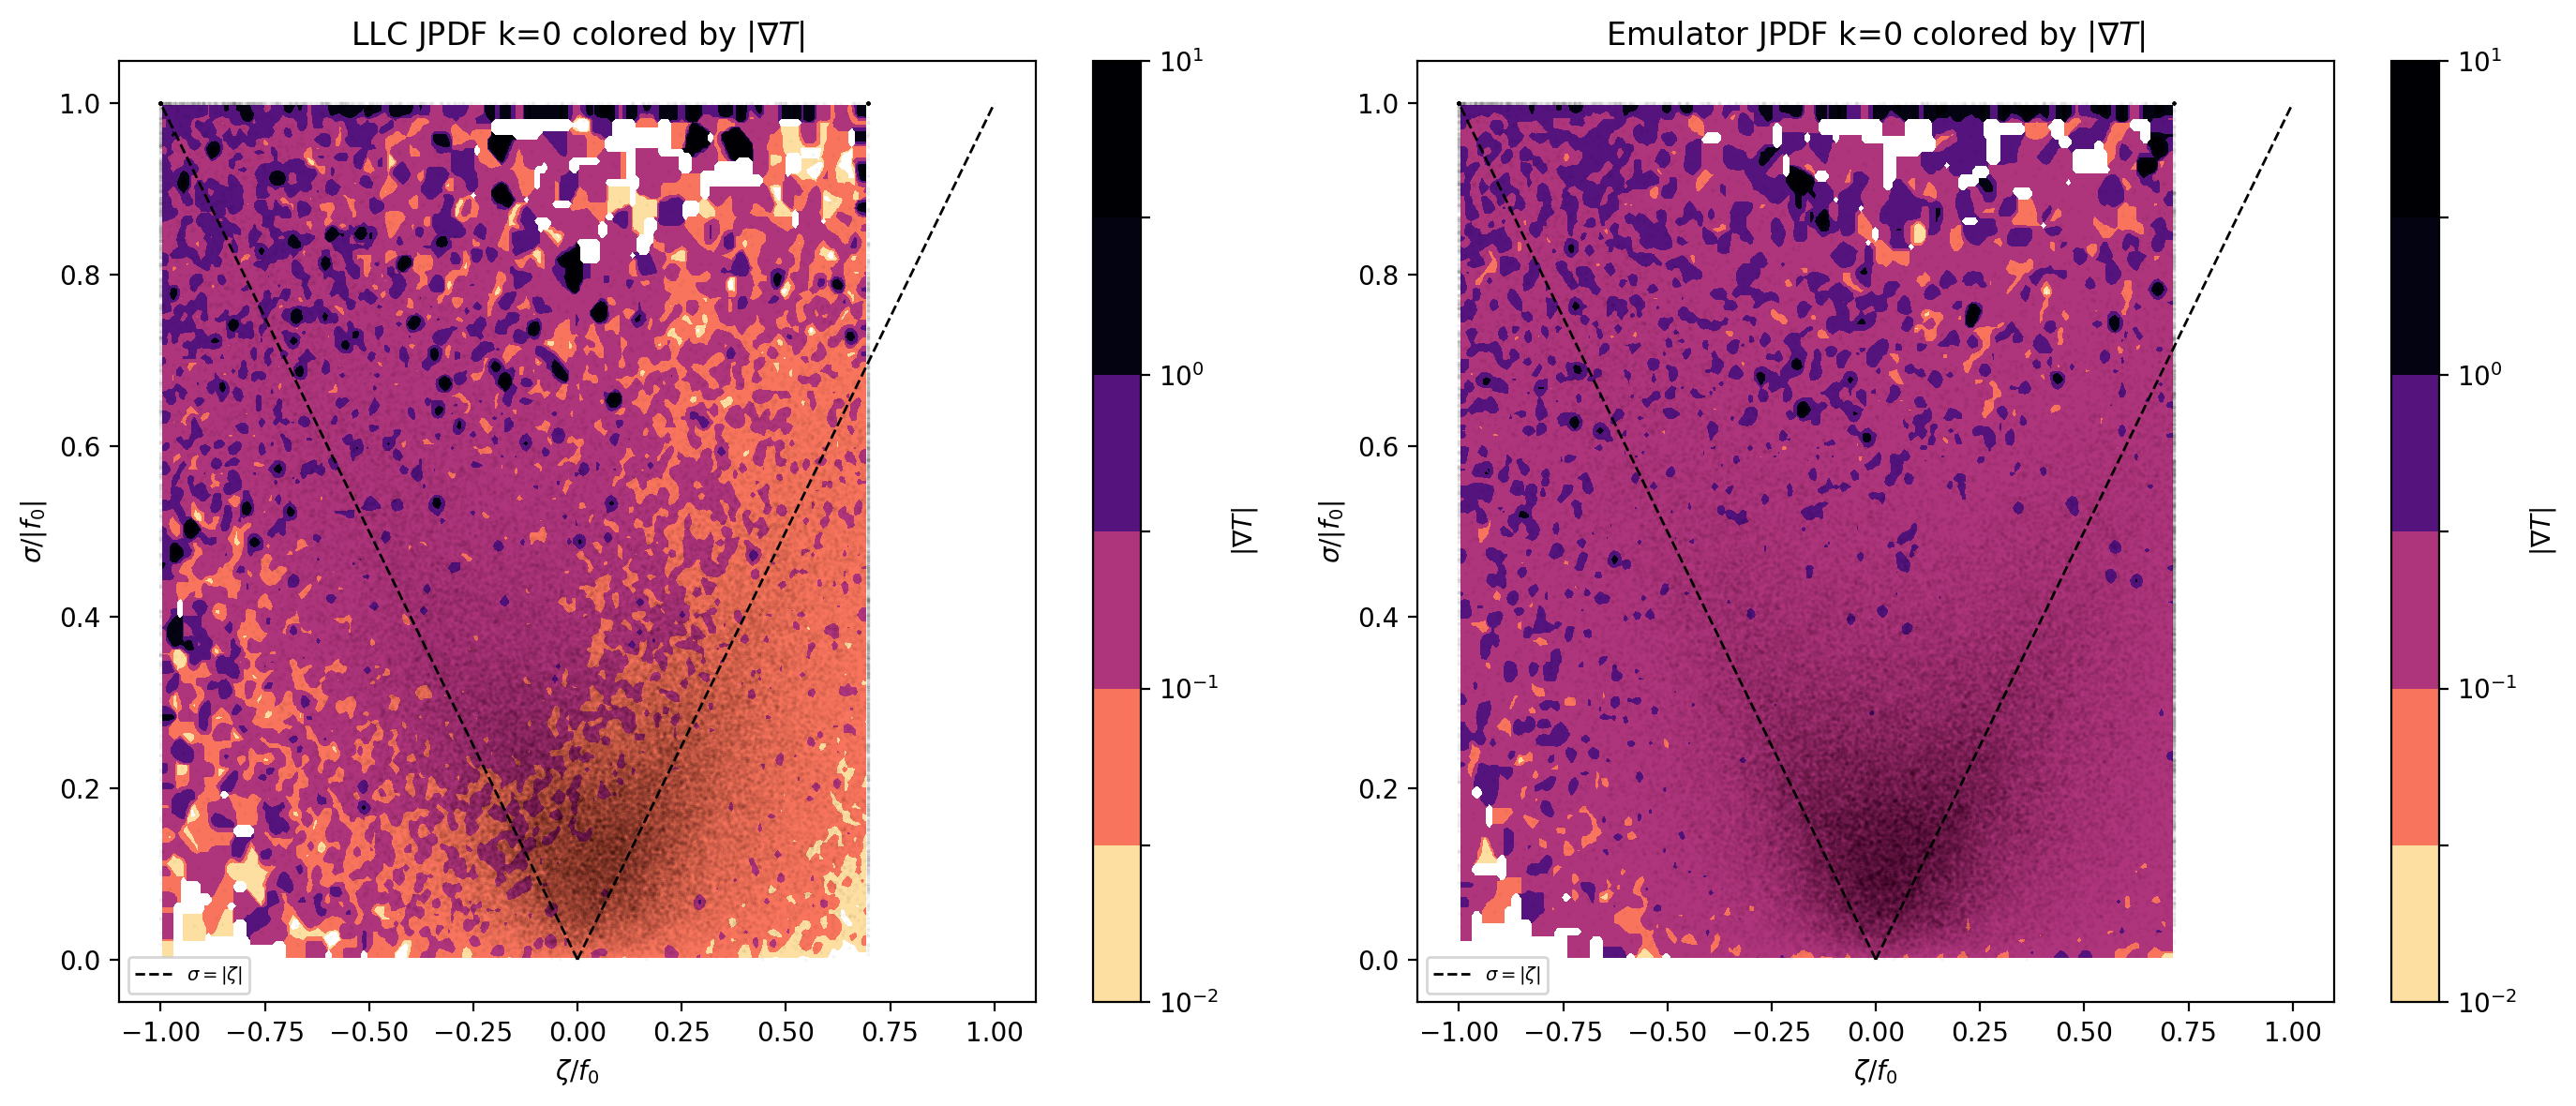

In [ ]:
# Process surface vorticity and strain for density
v = vort_hist_llc[0].flatten()
s = strain_hist_llc[0].flatten()
mask = ~(np.isnan(v) | np.isnan(s))
v = v[mask]; s = s[mask]
idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
v_sub = v[idx]; s_sub = s[idx]
counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
counts = gaussian_filter(counts, sigma=0.75)
counts = np.where(counts > 0, counts, np.nan)

log_min_d = np.floor(np.log10(np.nanmin(counts)))
log_max_d = np.ceil(np.log10(np.nanmax(counts)))
levels_d = 10 ** np.arange(log_min_d, log_max_d + 0.5, 0.5)

# Process surface vorticity, strain, and grad_T for grad_T plot
v = vort_hist_llc[0].flatten()
s = strain_hist_llc[0].flatten()
g = grad_T_hist_llc[0].flatten()
mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
v = v[mask]; s = s[mask]; g = g[mask]
idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
v_sub_g = v[idx]; s_sub_g = s[idx]; g_sub = g[idx]

nbins = 200
counts_g, xedges_g, yedges_g = np.histogram2d(v_sub_g, s_sub_g, bins=nbins)
g_sum, _, _ = np.histogram2d(v_sub_g, s_sub_g, bins=[xedges_g, yedges_g], weights=g_sub)

counts_smooth = gaussian_filter(counts_g, sigma=0.75)
g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)

g_mean = np.full_like(counts_smooth, np.nan)
valid = counts_smooth > 0
g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
g_mean = np.where(g_mean > 0, g_mean, np.nan)

log_min_g = np.floor(np.log10(np.nanpercentile(g_mean, 1)))
log_max_g = np.ceil(np.log10(np.nanpercentile(g_mean, 99)))
levels_g = 10 ** np.arange(log_min_g, log_max_g + 0.5, 0.5)

# Create figure with 2 panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

# Panel 1: Density
xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2
cf1 = ax1.contourf(xc, yc, counts.T, levels=levels_d, 
                   cmap='cividis', norm=LogNorm(vmin=10**log_min_d, vmax=10**log_max_d))
ax1.scatter(v_sub, s_sub, s=0.1, alpha=0.05, c='k')
lim = max(np.abs(v_sub).max(), s_sub.max())
ax1.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
ax1.plot([0, -lim], [0, lim], 'k--', linewidth=1)
cbar1 = plt.colorbar(cf1, ax=ax1, label='Count')
cbar1.ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax1.set_xlabel(r'$\zeta / f_0$')
ax1.set_ylabel(r'$\sigma / |f_0|$')
ax1.set_title('LLC JPDF k=0 (surface)')
ax1.legend(fontsize=7)

# Panel 2: grad_T
xc_g = (xedges_g[:-1] + xedges_g[1:]) / 2
yc_g = (yedges_g[:-1] + yedges_g[1:]) / 2
cf2 = ax2.contourf(xc_g, yc_g, g_mean.T, levels=levels_g, 
                   cmap='magma_r', norm=LogNorm(vmin=10**log_min_g, vmax=10**log_max_g))
ax2.scatter(v_sub_g, s_sub_g, s=0.1, alpha=0.05, color='k')
lim_g = max(np.abs(v_sub_g).max(), s_sub_g.max())
ax2.plot([0, lim_g], [0, lim_g], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
ax2.plot([0, -lim_g], [0, lim_g], 'k--', linewidth=1)
cbar2 = plt.colorbar(cf2, ax=ax2, label=r'$|\nabla T|$')
cbar2.ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax2.set_xlabel(r'$\zeta / f_0$')
ax2.set_ylabel(r'$\sigma / |f_0|$')
ax2.set_title('LLC JPDF k=0 colored by ' + r'$|\nabla T|$')
ax2.legend(fontsize=7)

plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_LLC_k0.png')
plt.show()

## Subset to two regions: high and low grad T

In [17]:
extent = 1

high_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent), i=slice(0,200),j=slice(490,690))
low_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent), i=slice(200,400),j=slice(490,690))

In [ ]:
omega = 7.2921e-5

# high_patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(high_patch['YC'].values)))

vort_llc = ((np.roll(high_patch['V'].values, -1, axis=3) - np.roll(high_patch['V'].values, 1, axis=3)) / 2 - \
            (np.roll(high_patch['U'].values, -1, axis=2) - np.roll(high_patch['U'].values, 1, axis=2)) / 2)

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
#vort_llc_normalized = np.clip(vort_llc_normalized, np.nanpercentile(vort_llc_normalized, 1), np.nanpercentile(vort_llc_normalized, 99))
vort_llc_normalized = vort_llc_normalized / np.nanmax(np.abs(vort_llc_normalized))

high_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)

omega = 7.2921e-5

# low_patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(low_patch['YC'].values)))

vort_llc = ((np.roll(low_patch['V'].values, -1, axis=3) - np.roll(low_patch['V'].values, 1, axis=3)) / 2 - \
            (np.roll(low_patch['U'].values, -1, axis=2) - np.roll(low_patch['U'].values, 1, axis=2)) / 2)

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
#vort_llc_normalized = np.clip(vort_llc_normalized, np.nanpercentile(vort_llc_normalized, 1), np.nanpercentile(vort_llc_normalized, 99))
vort_llc_normalized = vort_llc_normalized / np.nanmax(np.abs(vort_llc_normalized))

low_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)

In [ ]:
high_vis = high_patch.vorticity.isel(time=0,k=0)
low_vis = low_patch.vorticity.isel(time=0,k=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.5), dpi=200)

# LLC
cf1 = ax1.contourf(high_vis.coords.get('i', np.arange(high_vis.shape[-1])), \
    high_vis.coords.get('j', np.arange(high_vis.shape[-2])), high_vis, \
        cmap="magma", levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface vorticity time=0 high', fontsize=8)

cf2 = ax2.contourf(low_vis.coords.get('i', np.arange(low_vis.shape[-1])), \
    low_vis.coords.get('j', np.arange(low_vis.shape[-2])), low_vis, \
        cmap="magma", levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('llc surface vorticity time=0 low', fontsize=8)


In [ ]:
omega = 7.2921e-5

# high_patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(high_patch['YC'].values)))

u_x_llc = (np.roll(high_patch['U'].values, -1, axis=3) - np.roll(high_patch['U'].values, 1, axis=3)) / 2
u_y_llc = (np.roll(high_patch['U'].values, -1, axis=2) - np.roll(high_patch['U'].values, 1, axis=2)) / 2
v_x_llc = (np.roll(high_patch['V'].values, -1, axis=3) - np.roll(high_patch['V'].values, 1, axis=3)) / 2
v_y_llc = (np.roll(high_patch['V'].values, -1, axis=2) - np.roll(high_patch['V'].values, 1, axis=2)) / 2

sigma_n_llc = u_x_llc - v_y_llc
sigma_s_llc = v_x_llc + u_y_llc
sigma_llc = np.sqrt(sigma_n_llc**2 + sigma_s_llc**2)

sigma_llc_normalized = sigma_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
#sigma_llc_normalized = np.clip(sigma_llc_normalized, 0, np.nanpercentile(sigma_llc_normalized, 99))
sigma_llc_normalized = sigma_llc_normalized / np.nanmax(sigma_llc_normalized)

high_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_llc_normalized)


omega = 7.2921e-5

# low_patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(low_patch['YC'].values)))

u_x_llc = (np.roll(low_patch['U'].values, -1, axis=3) - np.roll(low_patch['U'].values, 1, axis=3)) / 2
u_y_llc = (np.roll(low_patch['U'].values, -1, axis=2) - np.roll(low_patch['U'].values, 1, axis=2)) / 2
v_x_llc = (np.roll(low_patch['V'].values, -1, axis=3) - np.roll(low_patch['V'].values, 1, axis=3)) / 2
v_y_llc = (np.roll(low_patch['V'].values, -1, axis=2) - np.roll(low_patch['V'].values, 1, axis=2)) / 2

sigma_n_llc = u_x_llc - v_y_llc
sigma_s_llc = v_x_llc + u_y_llc
sigma_llc = np.sqrt(sigma_n_llc**2 + sigma_s_llc**2)

sigma_llc_normalized = sigma_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
#sigma_llc_normalized = np.clip(sigma_llc_normalized, 0, np.nanpercentile(sigma_llc_normalized, 99))
sigma_llc_normalized = sigma_llc_normalized / np.nanmax(sigma_llc_normalized)

low_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_llc_normalized)

In [ ]:
high_vis = high_patch.strain.isel(time=0,k=0)
low_vis = low_patch.strain.isel(time=0,k=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.5), dpi=200)

# LLC
cf1 = ax1.contourf(high_vis.coords.get('i', np.arange(high_vis.shape[-1])), \
    high_vis.coords.get('j', np.arange(high_vis.shape[-2])), high_vis, \
        cmap="plasma", levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface strain time=0 high', fontsize=8)

cf2 = ax2.contourf(low_vis.coords.get('i', np.arange(low_vis.shape[-1])), \
    low_vis.coords.get('j', np.arange(low_vis.shape[-2])), low_vis, \
        cmap="plasma", levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('llc surface strain time=0 low', fontsize=8)

In [ ]:
# high_patch
Theta_llc = high_patch['Theta'].values  # load once

dT_di_llc = (np.roll(Theta_llc, -1, axis=3) - np.roll(Theta_llc, 1, axis=3)) / 2
dT_dj_llc = (np.roll(Theta_llc, -1, axis=2) - np.roll(Theta_llc, 1, axis=2)) / 2

# Gradient magnitude |∇T|
grad_T_llc = np.sqrt(dT_di_llc**2 + dT_dj_llc**2)

high_patch['grad_T'] = (('time', 'k', 'j', 'i'), grad_T_llc/np.nanmax(grad_T_llc))

# low_patch
Theta_llc = low_patch['Theta'].values  # load once

dT_di_llc = (np.roll(Theta_llc, -1, axis=3) - np.roll(Theta_llc, 1, axis=3)) / 2
dT_dj_llc = (np.roll(Theta_llc, -1, axis=2) - np.roll(Theta_llc, 1, axis=2)) / 2

# Gradient magnitude |∇T|
grad_T_llc = np.sqrt(dT_di_llc**2 + dT_dj_llc**2)

low_patch['grad_T'] = (('time', 'k', 'j', 'i'), grad_T_llc/np.nanmax(grad_T_llc))

In [ ]:
high_vis = high_patch.grad_T.isel(time=0,k=0)
low_vis = low_patch.grad_T.isel(time=0,k=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.5), dpi=200)

# LLC
cf1 = ax1.contourf(high_vis.coords.get('i', np.arange(high_vis.shape[-1])), \
    high_vis.coords.get('j', np.arange(high_vis.shape[-2])), high_vis, \
        cmap="magma_r", levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface grad_T time=0 high', fontsize=8)

cf2 = ax2.contourf(low_vis.coords.get('i', np.arange(low_vis.shape[-1])), \
    low_vis.coords.get('j', np.arange(low_vis.shape[-2])), low_vis, \
        cmap="magma_r", levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('llc surface grad_T time=0 low', fontsize=8)

In [ ]:
vort_hist_high = high_patch.vorticity.stack(vals=['time','i','j']).values
vort_hist_low = low_patch.vorticity.stack(vals=['time','i','j']).values

strain_hist_high = high_patch.strain.stack(vals=['time','i','j']).values
strain_hist_low = low_patch.strain.stack(vals=['time','i','j']).values

grad_T_hist_high = high_patch.grad_T.stack(vals=['time','i','j']).values
grad_T_hist_low = low_patch.grad_T.stack(vals=['time','i','j']).values

In [ ]:
# ============================================================
# Surface (k=0) JPDF
# ============================================================
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from scipy.ndimage import gaussian_filter

# --- Figure 1: Density ---
density_data = {}
for label, vort, strain in [('High', vort_hist_high, strain_hist_high),
                              ('Low', vort_hist_low, strain_hist_low)]:
    v = vort[0]  # k=0
    s = strain[0]
    mask = ~(np.isnan(v) | np.isnan(s))
    v = v[mask]; s = s[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
    counts = gaussian_filter(counts, sigma=0.75)
    counts = np.where(counts > 0, counts, np.nan)
    density_data[label] = (v_sub, s_sub, counts, xedges, yedges)

shared_vmin_d = min(np.nanmin(density_data['High'][2]), np.nanmin(density_data['Low'][2]))
shared_vmax_d = max(np.nanmax(density_data['High'][2]), np.nanmax(density_data['Low'][2]))
log_min_d = np.floor(np.log10(shared_vmin_d))
log_max_d = np.ceil(np.log10(shared_vmax_d))
levels_d = 10 ** np.arange(log_min_d, log_max_d + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)
for ax, label in [(ax1, 'High'), (ax2, 'Low')]:
    v_sub, s_sub, counts, xedges, yedges = density_data[label]
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    cf = ax.contourf(xc, yc, counts.T, levels=levels_d,
                     cmap='cividis', norm=LogNorm(vmin=shared_vmin_d, vmax=shared_vmax_d))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, c='k')
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    cbar = plt.colorbar(cf, ax=ax, label='Count')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$'); ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF k=0 (surface)')
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_density_k0_high_low.png')
plt.show()

# --- Figure 2: grad_T ---
gradT_data = {}
for label, vort, strain, grad_T in [('High', vort_hist_high, strain_hist_high, grad_T_hist_high),
                                      ('Low', vort_hist_low, strain_hist_low, grad_T_hist_low)]:
    v = vort[0]; s = strain[0]; g = grad_T[0]
    mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
    v = v[mask]; s = s[mask]; g = g[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]; g_sub = g[idx]
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
    g_sum, _, _ = np.histogram2d(v_sub, s_sub, bins=[xedges, yedges], weights=g_sub)
    counts_smooth = gaussian_filter(counts, sigma=0.75)
    g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)
    g_mean = np.full_like(counts_smooth, np.nan)
    valid = counts_smooth > 0
    g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
    g_mean = np.where(g_mean > 0, g_mean, np.nan)
    gradT_data[label] = (v_sub, s_sub, g_sub, g_mean, xedges, yedges)

shared_vmin_g = min(np.nanpercentile(gradT_data['High'][3], 1), np.nanpercentile(gradT_data['Low'][3], 1))
shared_vmax_g = max(np.nanpercentile(gradT_data['High'][3], 99), np.nanpercentile(gradT_data['Low'][3], 99))
log_min_g = np.floor(np.log10(shared_vmin_g))
log_max_g = np.ceil(np.log10(shared_vmax_g))
levels_g = 10 ** np.arange(log_min_g, log_max_g + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)
for ax, label in [(ax1, 'High'), (ax2, 'Low')]:
    v_sub, s_sub, g_sub, g_mean, xedges, yedges = gradT_data[label]
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    cf = ax.contourf(xc, yc, g_mean.T, levels=levels_g,
                     cmap='magma_r', norm=LogNorm(vmin=shared_vmin_g, vmax=shared_vmax_g))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, color='k')
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    cbar = plt.colorbar(cf, ax=ax, label=r'$|\nabla T|$')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$'); ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF k=0 colored by ' + r'$|\nabla T|$')
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_gradT_k0_high_low.png')
plt.show()